# Dependencies

Not all the required libraries are pre-installed on Colab, for example optuna and evaluate. Also transformers is locked to a specific version to mitigate issues with the custom model, which extends the sequence classification model of BERT. The kaleido library reinstall is related to graphs produced by optuna using plotly, which is needed to expoert them to PDFs.

In [1]:
!pip install -q optuna evaluate transformers==5.1.0 kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00


In [2]:
from datasets import concatenate_datasets, interleave_datasets, load_dataset, DatasetDict, Features, Value, load_from_disk
from transformers import AutoTokenizer, BertModel, AutoModelForSequenceClassification, BertForSequenceClassification, DistilBertForSequenceClassification, DistilBertModel, TrainingArguments, Trainer, PreTrainedConfig, EarlyStoppingCallback, DataCollatorWithPadding, pipeline
from transformers.pipelines.pt_utils import KeyDataset
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import evaluate
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data.dataloader import DataLoader
from torchsummary import summary
import optuna
from dataclasses import dataclass, field
from scipy.stats import wilcoxon, ttest_rel, normaltest

import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.auto import tqdm
import math
from enum import Enum
import json

# Global variables

Variables and values used in multiple places are all initialized here. The available GPUs are also detected, based on which the torch device type is set. It might not be necessary, but setting default device can prevent some errors or data being on different on wrong devices.

A predefined random seed value is set here as well, which is used to make randomized dataset operations deterministic, always resulting in identical splits in different initializations. Not using a set seet could for example result in samples being present in the training dataset in one execution and in the testing dataset in another, and if a model trained and then reloaded from disk, the results could be positively biased if test data was shared unintentionally.


The task definitions are in a simple list, but a more sophisticated data structure could also be used, especially if the tasks are used in multiple implementations. But for the context of a notebook this apprach works well enough. Since all of the datasets of hugginface can have different splits, some wihtout annotations, the subset and splits to be used are also defined here.

The specifications of the datasets of all tasks in also defined, with the total number or samples required and the ratios they are split into three different subsets.

In [3]:
if torch.cuda.is_available():
    DEVICE_TYPE = "cuda"
else:
    DEVICE_TYPE = "cpu"

# This should cover most cases where the device would need to be manually set
# This actually breaks daloaders, but only sometimes
torch.set_default_device(DEVICE_TYPE)

print(f"Using {DEVICE_TYPE} device type")

Using cuda device type


In [4]:
# Useful to get the same samples in the same splits on different executions
RANDOM_SEED = 8953

In [5]:
task_definitions = [
    # Target task
    {
        "name": "emotion",
        "labels": {
            0: "sadness",
            1: "joy",
            2: "love",
            3: "anger",
            4: "fear",
            5: "surprise"
        },
        "dataset_spec": {
            "path": "dair-ai/emotion",
            "subset": "unsplit",
            "splits": ["train"],
            "columns": {
                "input_columns": ["text"],
                "drop": [],
                "rename": {
                    "label": "labels"
                }
            }
        }
    },
    # GLUE benchmark
    {
        "name": "cola",
        "labels": {
            0: "acceptable",
            1: "unacceptable"
        },
        "dataset_spec": {
            "path": "nyu-mll/glue",
            "subset": "cola",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text"],
                "drop": ["idx"],
                "rename": {
                    "sentence": "text",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "sst2",
        "labels": {
            0: "negative",
            1: "positive"
        },
        "dataset_spec": {
            "path": "nyu-mll/glue",
            "subset": "sst2",
            "splits": ["train"],
            "columns": {
                "input_columns": ["text"],
                "drop": ["idx"],
                "rename": {
                    "sentence": "text",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "mrpc",
        "labels": {
            0: "not equivalent",
            1: "equivalent"
        },
        "dataset_spec": {
            "path": "nyu-mll/glue",
            "subset": "mrpc",
            "splits": ["train", "validation", "test"],
            "columns": {
                "input_columns": ["text1", "text2"],
                "drop": ["idx"],
                "rename": {
                    "sentence1": "text1",
                    "sentence2": "text2",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "qqp",
        "labels": {
            0: "not duplicate",
            1: "duplicate",
        },
        "dataset_spec": {
            "path": "nyu-mll/glue",
            "subset": "qqp",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text1", "text2"],
                "drop": ["idx"],
                "rename": {
                    "question1": "text1",
                    "question2": "text2",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "mnli",
        "labels": {
            0: "entailment",
            1: "neutral",
            2: "contradiction"
        },
        "dataset_spec": {
            "path": "nyu-mll/glue",
            "subset": "mnli",
            "splits": ["train"],
            "columns": {
                "input_columns": ["text1", "text2"],
                "drop": ["idx"],
                "rename": {
                    "premise": "text1",
                    "hypothesis": "text2",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "qnli",
        "labels": {
            0: "entailment",
            1: "not entailment",
        },
        "dataset_spec": {
            "path": "nyu-mll/glue",
            "subset": "qnli",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text1", "text2"],
                "drop": ["idx"],
                "rename": {
                    "question": "text1",
                    "sentence": "text2",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "rte",
        "labels": {
            0: "entailment",
            1: "not entailment",
        },
        "dataset_spec": {
            "path": "nyu-mll/glue",
            "subset": "rte",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text1", "text2"],
                "drop": ["idx"],
                "rename": {
                    "sentence1": "text1",
                    "sentence2": "text2",
                    "label": "labels"
                }
            }
        }
    },
    # SuperGLUE benchmark
    {
        "name": "cb",
        "labels": {
            0: "entailment",
            1: "contradiction",
            2: "neutral"
        },
        "dataset_spec": {
            "path": "aps/super_glue",
            "subset": "cb",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text1", "text2"],
                "drop": ["idx"],
                "rename": {
                    "premise": "text1",
                    "hypothesis": "text2",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "multirc",
        "labels": {
            0: "false",
            1: "true",
        },
        "dataset_spec": {
            "path": "aps/super_glue",
            "subset": "multirc",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text1", "text2", "text3"],
                "drop": ["idx"],
                "rename": {
                    "question": "text1",
                    "answer": "text2",
                    "paragraph": "text3",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "wic",
        "labels": {
            0: "false",
            1: "true"
        },
        "dataset_spec": {
            "path": "aps/super_glue",
            "subset": "wic",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text1", "text2", "text3"],
                "drop": ["idx", "start1", "start2", "end1", "end2"],
                "rename": {
                    "word": "text1",
                    "sentence1": "text2",
                    "sentence2": "text3",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "wsc",
        "labels": {
            0: "false",
            1: "true",
        },
        "dataset_spec": {
            "path": "aps/super_glue",
            "subset": "wsc",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text1", "text2", "text3"],
                "drop": ["idx", "span1_index", "span2_index"],
                "rename": {
                    "text": "text1",
                    "span1_text": "text2",
                    "span2_text": "text3",
                    "label": "labels"
                }
            }
        }
    },
    {
        "name": "boolq",
        "labels": {
            0: "false",
            1: "true",
        },
        "dataset_spec": {
            "path": "aps/super_glue",
            "subset": "boolq",
            "splits": ["train", "validation"],
            "columns": {
                "input_columns": ["text1", "text2"],
                "drop": ["idx"],
                "rename": {
                    "question": "text1",
                    "passage": "text2",
                    "label": "labels"
                }
            }
        }
    },
]

dataset_spec = {
    "total": 20000,
    "splits": {
        "train": 0.8,
        "validate": 0.1,
        "test": 0.1
    }
}

# Datasets

## Generate new datasets

As multiple datasets are used in this approach, some utility methods are defined to help with their preprocessing. A general method is defined for loading a specific huggingface dataset with specific splits from a specific subset. In the implementation all the requested splits of a dataset are merged and shuffled deterministically, and if the combined number of samples is below the set target, oversampling is performed to reach it. Oversampling is done only after the datasets have been split to the final three subsets, which doesn't result in samples being shared between them, as would be the case if oversampling was done before the split.

In [6]:
# Use the dataset specifications to split one merged dataset
def train_validate_test_split(dataset, specs):
    train_test = dataset.train_test_split(
        train_size=specs["splits"]["train"] + specs["splits"]["validate"],
        test_size=specs["splits"]["test"],
        shuffle=False,
        )

    train_validate = train_test["train"].train_test_split(
        # Calculate a new ratio for the train + validate subset of samples
        train_size=specs["splits"]["train"] / (specs["splits"]["train"] + specs["splits"]["validate"]),
        test_size=1 - specs["splits"]["train"] / (specs["splits"]["train"] + specs["splits"]["validate"]),
        shuffle=False,
        )

    return DatasetDict({
        "train": train_validate["train"],
        "validate": train_validate["test"],
        "test": train_test["test"]
    })

In [7]:
# Load and process datasets for each task
for task_index, task in enumerate(task_definitions):
  splits = []

  for split in task["dataset_spec"]["splits"]:
    # Seed forces the selection to be deterministic, assuming the sample order is not changed in the reposiroty
    splits.append(load_dataset(task["dataset_spec"]["path"], task["dataset_spec"]["subset"], split=split, streaming=False).shuffle(seed=RANDOM_SEED))

  # Whatever subsets or splits the dataset repository uses, just concatenate them
  # To make this faster, limit the size to the desired total sample size
  concatenated_splits = concatenate_datasets(splits).select(range(dataset_spec["total"] if sum(len(split) > dataset_spec["total"] for split in splits) else sum(len(split) for split in splits)))

  # Split dataset to the desired ratios, which is done before oversampling to not leak samples between the splits
  task_dataset = train_validate_test_split(concatenated_splits, dataset_spec)

  # Check tha the splits are of sufficient size, otherwise oversample, also do any processing which is applied to all splits
  for split in task_dataset.keys():
    split_target_size = int(dataset_spec["total"] * dataset_spec["splits"][split])
    split_actual_size =  len(task_dataset[split])


    if split_actual_size < split_target_size:
      print(f"Note! Task {task["name"]} split {split} needed oversampling: {split_actual_size} -> {split_target_size} ({split_target_size / split_actual_size :.1f}x increase)")

      # Oversampling is done at split level to not leak samples between them
      # Between multiplying the split it is shuffled to make sure the change of a sample being oversamples are all the same
      oversampled_split = concatenate_datasets([task_dataset[split]] * math.ceil(split_target_size / split_actual_size)).shuffle(seed=RANDOM_SEED).select(range(split_target_size))

      task_dataset[split] = oversampled_split
    elif split_actual_size > split_target_size:
      # Is the split ends up being a bit larger than the target make it a bit smaller
      task_dataset[split] = task_dataset[split].select(range(split_target_size))

    # Drop or rename columns is specified
    task_dataset[split] = task_dataset[split].remove_columns(task["dataset_spec"]["columns"]["drop"])

    for old, new in task["dataset_spec"]["columns"]["rename"].items():
      task_dataset[split] = task_dataset[split].rename_column(old, new)

    # Add a task index feature to differentiate datasets during training
    task_name_feature = [task["name"]] * len(task_dataset[split])

    task_dataset[split] = task_dataset[split].add_column("task_name", task_name_feature)


  # Set to be torch compatible
  task_dataset.set_format("torch", device=DEVICE_TYPE)

  task["dataset"] = task_dataset

README.md: 0.00B [00:00, ?B/s]

unsplit/train-00000-of-00001.parquet:   0%|          | 0.00/26.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/416809 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/16000 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Flattening the indices:   0%|          | 0/16000 [00:00<?, ? examples/s]

Note! Task boolq split validate needed oversampling: 1270 -> 2000 (1.6x increase)


Flattening the indices:   0%|          | 0/2000 [00:00<?, ? examples/s]

Note! Task boolq split test needed oversampling: 1270 -> 2000 (1.6x increase)


Flattening the indices:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [8]:
# Check the dataset label formats
for task in task_definitions:
  print(f"Task {task["name"]} test subset labels: {task["dataset"]["test"]["labels"][:10]}")

# And the columns
for task in task_definitions:
  print(f"Task {task["name"]} test subset features: {task["dataset"]["test"].features.keys()}")

Task emotion test subset labels: tensor([0, 1, 1, 1, 0, 3, 1, 0, 2, 1], device='cuda:0')
Task cola test subset labels: tensor([1, 0, 0, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')
Task sst2 test subset labels: tensor([0, 0, 1, 0, 1, 1, 0, 0, 1, 0], device='cuda:0')
Task mrpc test subset labels: tensor([1, 0, 0, 0, 0, 0, 0, 1, 1, 0], device='cuda:0')
Task qqp test subset labels: tensor([1, 1, 1, 0, 0, 1, 1, 0, 1, 1], device='cuda:0')
Task mnli test subset labels: tensor([1, 0, 0, 2, 0, 2, 2, 2, 1, 0], device='cuda:0')
Task qnli test subset labels: tensor([0, 0, 0, 1, 0, 0, 1, 0, 1, 1], device='cuda:0')
Task rte test subset labels: tensor([0, 0, 0, 1, 0, 0, 0, 1, 1, 1], device='cuda:0')
Task cb test subset labels: tensor([1, 0, 1, 0, 0, 1, 0, 0, 1, 1], device='cuda:0')
Task multirc test subset labels: tensor([0, 1, 0, 0, 1, 0, 1, 1, 0, 1], device='cuda:0')
Task wic test subset labels: tensor([0, 0, 1, 0, 1, 0, 1, 1, 1, 1], device='cuda:0')
Task wsc test subset labels: tensor([1, 0, 0, 0, 0, 1

In [9]:
# Also get completely unseen data for statistical significance testing, which has no overlap with the emotion dataset in task_definitions
emotion_dataset_unseen = load_dataset(task_definitions[0]["dataset_spec"]["path"], task_definitions[0]["dataset_spec"]["subset"], split="train", streaming=False).shuffle(seed=RANDOM_SEED).select(range(100000, 150000))

emotion_dataset_unseen = emotion_dataset_unseen.add_column("task_name", ["emotion"] * len(emotion_dataset_unseen)).rename_column("label", "labels")

emotion_dataset_unseen.set_format("torch", device=DEVICE_TYPE)

emotion_dataset_unseen

Flattening the indices:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'task_name'],
    num_rows: 50000
})

## Dataset details

Here graph figures are generated for the emotion detection target task dataset, which are applicable for both approaches. The class distribution of emotion classes is done for all splits to validate their similarity and a histogram is generated for the lenghts for the samples.

In [ ]:
# Chart of class distribution in the dataset splits
chart_labels = list(map(lambda value: value.capitalize(), task_definitions[0]["labels"].values()))
chart_label_colors = ["tab:black", "tab:black", "tab:black", "tab:black", "tab:black", "tab:black"]
chart_class_counts = {
    "train": np.unique(task_definitions[0]["dataset"]["train"]["labels"], return_counts=True)[1],
    "validate": np.unique(task_definitions[0]["dataset"]["validate"]["labels"], return_counts=True)[1],
    "test": np.unique(task_definitions[0]["dataset"]["test"]["labels"], return_counts=True)[1]
}

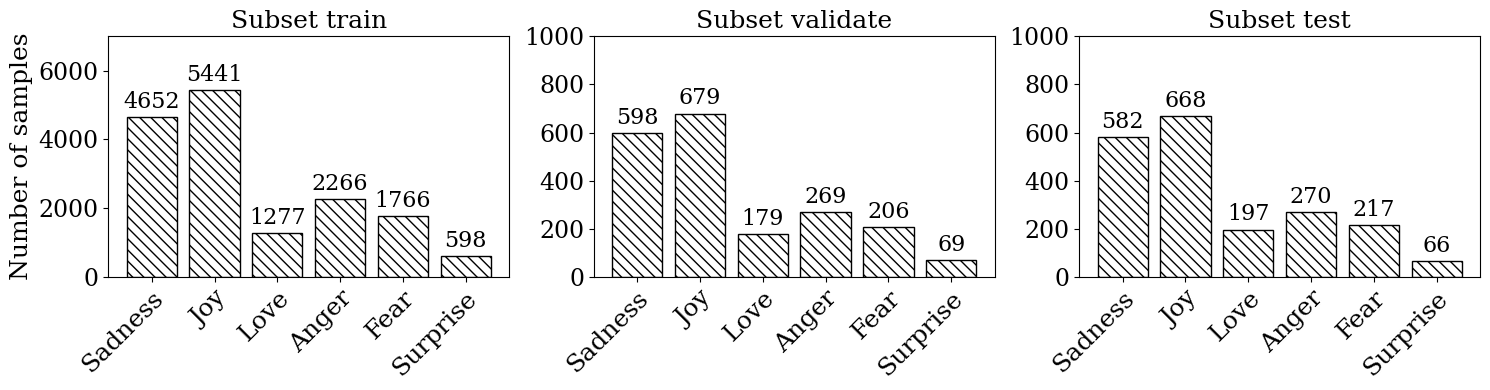

In [ ]:
fig, axes = plt.subplots(1, 3)

fig.set_figwidth(15)
fig.set_figheight(4)

small_fontsize = 17
large_fontsize = 18

for index, (split, counts) in enumerate(chart_class_counts.items()):
  bar_container = axes[index].bar(chart_labels, chart_class_counts[split], width=0.8, color="white", edgecolor="black", hatch="\\\\\\")
  axes[index].set(ylabel="Number of samples" if index == 0 else None, title=f"Subset {split}", ylim=(0, math.ceil(max(chart_class_counts[split] * 1.15) / 1000) * 1000))
  axes[index].bar_label(bar_container, padding=3, fontsize=16)
  xlabels = axes[index].get_xticklabels()
  plt.setp(xlabels, rotation=45, ha="right", rotation_mode="anchor", fontsize=large_fontsize)

plt.rc("font", family="serif", serif="DejaVu Serif")
plt.rc('axes', titlesize=large_fontsize)
plt.rc('axes', labelsize=large_fontsize)
plt.rc('xtick', labelsize=large_fontsize)
plt.rc('ytick', labelsize=small_fontsize)

fig.tight_layout()

plt.savefig("emotion_dataset_class_distribution.pdf")

plt.show()

In [ ]:
# Get a list of samples lenghts per split
text_sample_lenghts = {
    "train": list(map(len, task_definitions[0]["dataset"]["train"]["text"])),
    "validate": list(map(len, task_definitions[0]["dataset"]["validate"]["text"])),
    "test": list(map(len, task_definitions[0]["dataset"]["test"]["text"]))
}

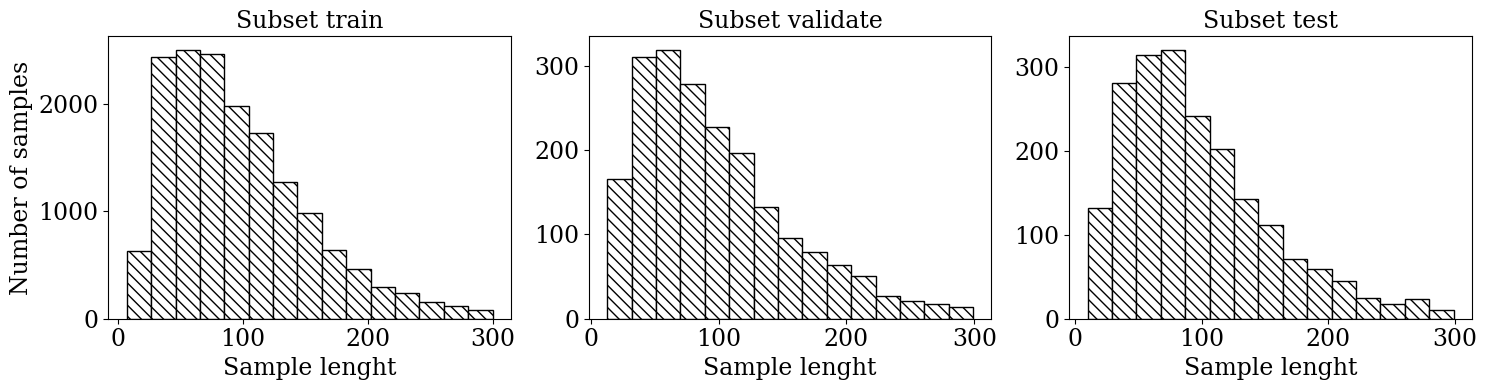

In [ ]:
# Create histograms of emotion dataset text samle lentghs
fig, axes = plt.subplots(1, 3)

fig.set_figwidth(15)
fig.set_figheight(4)

small_fontsize = 17
large_fontsize = 18

for index, (split, lenghts) in enumerate(text_sample_lenghts.items()):
  axes[index].hist(text_sample_lenghts[split], color="white", edgecolor="black", hatch="\\\\\\", bins=15)
  axes[index].set(ylabel="Number of samples" if index == 0 else None, title=f"Subset {split}")
  axes[index].set_xlabel("Sample lenght")

plt.rc("font", family="serif", serif="DejaVu Serif")
plt.rc('axes', titlesize=large_fontsize)
plt.rc('axes', labelsize=large_fontsize)
plt.rc('xtick', labelsize=large_fontsize)
plt.rc('ytick', labelsize=large_fontsize)

fig.tight_layout()

plt.savefig("emotion_dataset_lenght_distribution.pdf")

plt.show()

## Save datasets to disk

No avoid redownloading the datasets each time a new Python environment is loaded, they can be saved and packaged on the disk in a convenient to download format. With this inter-dataset approach this is not that important or nedeed, as no fine-tuning or distillation feature generation is done.

In [ ]:
for task_index in range(len(task_definitions)):
  # Save dataset to the disk
  task_datasets[task_index].save_to_disk(f"task_datasets/{task_definitions[task_index]["name"]}")

# And zip it for easier storage
!zip -r task_datasets.zip task_datasets

NameError: name 'task_datasets' is not defined

## Load datasets from disk

The same steps as saving but in the opposite direction.

In [ ]:
!unzip -o task_datasets.zip -d .

task_datasets = []

for task_index, task in enumerate(task_definitions[:2]):
  directory_name = f"task_datasets/{task_definitions[task_index]["name"]}"

  task_dataset = load_from_disk(directory_name)
  task_dataset.set_format("torch", device=DEVICE_TYPE)

  task_datasets.append(task_dataset)

# Model and trainer

A customized model and trained are defined for this approach, similarly as with the intra-dataset approach. The difference is, that in this approach only one task is "active" for each batch, requiring a mechanism to detect which one should be used within the forward method of the model.

The multi-task BERT-based model is formed by exteding the DistilBertForSequenceClassification class from the transformers library, in which a module dictionary is used to register the task-specific layers. Since multiple datasets are used, a customized dataset class is also defined, which is compatible with the trainer functionality of the transformers library. In practive the customized dataset class creates single-task batches and schedules them according to the scheduling strategy. An important example/base for the customized dataset class is https://colab.research.google.com/github/zphang/zphang.github.io/blob/master/files/notebooks/Multi_task_Training_with_Transformers_NLP.ipynb#scrollTo=JdUbpAIZzWce.

As with the intra-dataset approach, customized trainer arguments and trainer are defined, which support the non-standard dataset and training scenario. The arguments include the used sampling strategy and the trained includes functionality to produce transformers-compatible datasets.



In [10]:
class MultiTaskDistilBertForSequenceClassification(DistilBertForSequenceClassification):
    def __init__(self, config: PreTrainedConfig, output_dims):
        super().__init__(config)
        self.config = config

        self.distilbert = DistilBertModel(config)

        # ModuleDict is easier since indexes might be skipped
        self.pre_classifiers = nn.ModuleDict()
        self.classifiers = nn.ModuleDict()

        # The modules aren't correctly registered with list comprehension which breaks checkpoint saving, so a for loop is needed here
        for task_name, output_dim in output_dims.items():
          # ModuleDict doesn't support integers to they need to be converted to strings
          self.pre_classifiers[task_name] = nn.Linear(config.dim, config.dim)
          self.classifiers[task_name] = nn.Linear(config.dim, output_dim)

        self.dropout = nn.Dropout(config.seq_classif_dropout)
        self.relu = nn.ReLU()

        # Initialize weights and apply final processing
        self.post_init()

    def forward(
        self,
        input_ids: torch.Tensor | None = None,
        attention_mask: torch.Tensor | None = None,
        inputs_embeds: torch.Tensor | None = None,
        labels: torch.LongTensor | None = None,
        position_ids: torch.Tensor | None = None,
        task_name: torch.Tensor | None = None,
        **kwargs,
    ):
        distilbert_output = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            inputs_embeds=inputs_embeds,
            position_ids=position_ids,
            **kwargs,
        )

        hidden_state = distilbert_output[0]  # (bs, seq_len, dim)
        pooled_output = hidden_state[:, 0]  # (bs, dim)

        if task_name == None:
          task_name = "emotion"
        else:
          task_name = task_name[0]

        task_pooled_output = self.pre_classifiers[task_name](pooled_output) # (bs, dim)
        task_pooled_output = self.relu(task_pooled_output) # (bs, dim)
        task_pooled_output = self.dropout(task_pooled_output) # (bs, dim)
        output_logits = self.classifiers[task_name](task_pooled_output) # (bs, output_dim or the task)

        return {
            "output_logits": output_logits,
            "last_hidden_state": distilbert_output.last_hidden_state
        }

In [11]:
class MultitaskSamplingStrategy(Enum):
  RANDOM = "random"
  SEQUENTIAL = "sequential"
  ALTERNATING = "alternating"

class MultiTaskDataset:
  def __init__(self, task_datasets, mtl_sampling_strategy):
    self.task_datasets = task_datasets
    self.task_num_batches = [len(task_dataset) for task_dataset in task_datasets]
    self.mtl_sampling_strategy = mtl_sampling_strategy

  def __len__(self):
    return sum(self.task_num_batches)

  def __iter__(self):
    # Shuffle batches of all tasks randomly, so that all tasks have the same amount of samples and will be trained evenly
    # For larger dataset size differences annealed sampling could be considered, at least if not using oversampling
    batch_task_choices = []

    if self.mtl_sampling_strategy == MultitaskSamplingStrategy.RANDOM:
      for task_index in range(len(self.task_datasets)):
        batch_task_choices += [task_index] * self.task_num_batches[task_index]

      batch_task_choices = np.array(batch_task_choices)

      np.random.shuffle(batch_task_choices)
    elif self.mtl_sampling_strategy == MultitaskSamplingStrategy.SEQUENTIAL:
      for task_index in reversed(range(len(self.task_datasets))):
        batch_task_choices += [task_index] * self.task_num_batches[task_index]

      batch_task_choices = np.array(batch_task_choices)
    elif self.mtl_sampling_strategy == MultitaskSamplingStrategy.ALTERNATING:
      task_batches = []

      for task_index in range(len(self.task_datasets)):
        task_batches.append([task_index] * self.task_num_batches[task_index])

      batch_task_choices = np.array([i for j in zip(*task_batches) for i in j])

    task_iterators = list(map(lambda task_dataset: iter(task_dataset), self.task_datasets))

    # Yield batches from tasks in the shuffled order
    for task_index in batch_task_choices:
      yield next(task_iterators[task_index])

In [12]:
@dataclass
class MultiTaskTrainingArguments(TrainingArguments):
  mtl_sampling_strategy: MultitaskSamplingStrategy = MultitaskSamplingStrategy.RANDOM

class MultiTaskTrainer(Trainer):

  def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
    labels = inputs.pop("labels")

    outputs = model(**inputs, return_dict=True, output_hidden_states=True)
    output_logits = outputs["output_logits"]

    # Loss functions
    ce_loss = nn.CrossEntropyLoss()

    # Hard loss
    hard_loss = ce_loss(output_logits, labels)

    overall_loss = hard_loss

    if return_outputs:
      return overall_loss, {"outputs": output_logits, "loss": overall_loss}
    else:
      return overall_loss

  def get_single_dataloader(self, dataset, batch_size):
    return DataLoader(
        dataset,
        batch_size=batch_size,
    )

  def get_train_dataloader(self):
    return MultiTaskDataset([self.get_single_dataloader(dataset, self.args.train_batch_size) for dataset in self.train_dataset], self.args.mtl_sampling_strategy)

  def get_eval_dataloader(self, eval_dataset):
    return MultiTaskDataset([self.get_single_dataloader(dataset, self.args.eval_batch_size) for dataset in eval_dataset], self.args.mtl_sampling_strategy)

# Tokenization

The tokenization performed here is non-stadard due to the multiple datasets, some of which have multple input features. The tokenizer of the DistilBERT model only works correctly with 2 input features, which is concatenates using the [SEP] token, but some auxiliary tasks used include 3 input features. The input features are defined in the task specificions, which are used to merge them manually with the [SEP] token.

In [13]:
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

for task in task_definitions:
  # We need to concatenate the inputs manually with the [SEP] token, since the tokenizer only works correctly with 2 and some tasks use 3
  concat_examples = lambda examples: list(map(f" {tokenizer.sep_token} ".join, zip(*[examples[column_name] for column_name in task["dataset_spec"]["columns"]["input_columns"]])))

  task["dataset"] = task["dataset"].map(lambda examples: tokenizer(concat_examples(examples), padding="max_length", truncation=True, max_length=256, return_tensors="pt"), batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [14]:
# Also tokenize the larger unseen test dataset
emotion_dataset_unseen = emotion_dataset_unseen.map(lambda samples: tokenizer(samples["text"], padding="max_length", truncation=True, max_length=256, return_tensors="pt"), batched=True)

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

# Only emotion detection baseline evaluation

In this section the baseline metrics are calculated for both approaches, where only the emotion detection task learned by fine-tuning the DistilBERT model. The shared hyperparameters are the same here as with the model instances with auxiliary tasks, so hyperparameter optimization is not performed here.

The embedding visualization for the baseline model and the macro F1 metrics for the unseen test sets used in the statistical significance calculation are also generated here, so there is no need to train in multple times for the two approaches.

In [15]:
metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

training_args = MultiTaskTrainingArguments(
    output_dir="multitask_classifier",
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    logging_strategy="steps",
    logging_steps=200,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    learning_rate=2e-5,
    mtl_sampling_strategy=MultitaskSamplingStrategy.RANDOM
)

output_dims = {
    task_definitions[0]["name"]: len(task_definitions[0]["labels"]),
}

baseline_model = MultiTaskDistilBertForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", output_dims=output_dims)

trainer = MultiTaskTrainer(
    model=baseline_model,
    args=training_args,
    train_dataset=[task_definitions[0]["dataset"]["train"]],
    eval_dataset=[task_definitions[0]["dataset"]["validate"]],
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

MultiTaskDistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                            | Status     | 
-------------------------------+------------+-
vocab_transform.bias           | UNEXPECTED | 
vocab_layer_norm.weight        | UNEXPECTED | 
vocab_projector.bias           | UNEXPECTED | 
vocab_transform.weight         | UNEXPECTED | 
vocab_layer_norm.bias          | UNEXPECTED | 
pre_classifiers.emotion.weight | MISSING    | 
classifiers.emotion.bias       | MISSING    | 
pre_classifiers.emotion.bias   | MISSING    | 
pre_classifier.weight          | MISSING    | 
classifier.weight              | MISSING    | 
classifiers.emotion.weight     | MISSING    | 
classifier.bias                | MISSING    | 
pre_classifier.bias            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the chec

Step,Training Loss,Validation Loss,F1
200,1.020450,0.453005,0.745760
400,0.353712,0.243415,0.878723
600,0.235888,0.205022,0.875461
800,0.163439,0.181295,0.887490
1000,0.142510,0.199212,0.878257
1200,0.114763,0.180470,0.895076
1400,0.111107,0.193783,0.884560
1600,0.099979,0.182203,0.886720
1800,0.084527,0.173833,0.886745
2000,0.090642,0.171409,0.882661


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2500, training_loss=0.20711576290130615, metrics={'train_runtime': 792.9674, 'train_samples_per_second': 100.887, 'train_steps_per_second': 3.153, 'total_flos': 5371834859520000.0, 'train_loss': 0.20711576290130615, 'epoch': 5.0})

In [ ]:
# Evaluate using the test set
test_set_predictions_baseline_model = trainer.predict(task_definitions[0]["dataset"]["test"])[0]

print(classification_report(task_definitions[0]["dataset"]["test"].with_format("numpy")["labels"], np.argmax(test_set_predictions_baseline_model, axis=1), digits=4, target_names=dict([(value, key) for key, value in task_definitions[0]["labels"].items()])))

              precision    recall  f1-score   support

     sadness     0.9572    0.9605    0.9588       582
         joy     0.9482    0.9326    0.9404       668
        love     0.8465    0.8680    0.8571       197
       anger     0.9197    0.9333    0.9265       270
        fear     0.8750    0.9355    0.9042       217
    surprise     0.9608    0.7424    0.8376        66

    accuracy                         0.9285      2000
   macro avg     0.9179    0.8954    0.9041      2000
weighted avg     0.9294    0.9285    0.9284      2000



In [ ]:
# Visualization of the embeddings produced by the baseline model
mean_last_hidden_states = np.empty(shape=(0,768))
labels_numpy = task_definitions[0]["dataset"]["test"].with_format("numpy")["labels"][:1000]

# Limit the samples to half the size to keep the plot more readable
for batch in range(int(len(task_definitions[0]["dataset"]["test"]) / 2 / 100)):
  range_start = batch * 100
  range_end = batch * 100 + 100

  with torch.no_grad():
    batch_last_hidden_states = baseline_model(**task_definitions[0]["dataset"]["test"][range_start:range_end], return_dict=True, output_hidden_states=True)["last_hidden_state"]

    input_mask_expanded = task_definitions[0]["dataset"]["test"][range_start:range_end]["attention_mask"].unsqueeze(-1).expand(batch_last_hidden_states.size()).float()
    mean_embeddings = torch.sum(batch_last_hidden_states * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    mean_last_hidden_states = np.concatenate((mean_last_hidden_states, mean_embeddings.detach().cpu().numpy()), axis=0)

print(mean_last_hidden_states.shape)

(1000, 768)


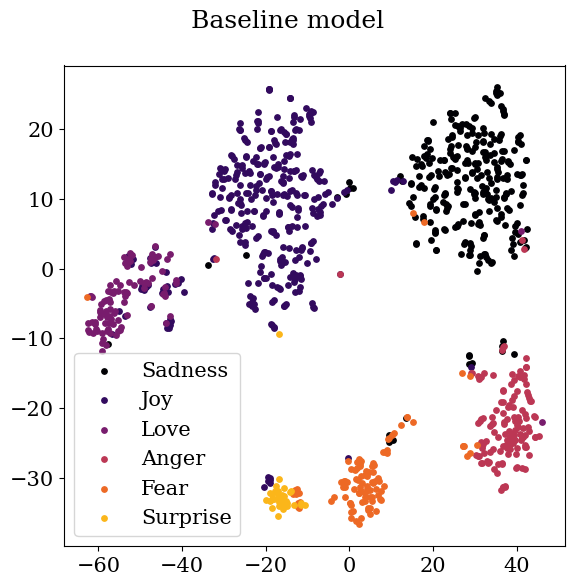

In [ ]:
pca = PCA(n_components=50)

pca_mean_embeddings_pca = pca.fit_transform(mean_last_hidden_states)

t_sne = TSNE(n_components=2)

pca_mean_embeddings_t_sne = t_sne.fit_transform(pca_mean_embeddings_pca)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot()

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 15
})

markers = ["o", "s", "*", "v", "D", "p"]
colors = plt.get_cmap("inferno")(np.linspace(0, 1, 7)[:6])

fig.suptitle("Baseline model")

for label_index, color, marker in zip(range(len(task_definitions[0]["labels"].keys())), colors, markers):
  sample_indexes = [i for i, x in enumerate(labels_numpy) if x == label_index]

  label = task_definitions[0]["labels"][label_index].capitalize()

  ax.scatter(pca_mean_embeddings_t_sne[sample_indexes, 0], pca_mean_embeddings_t_sne[sample_indexes, 1], s=15, color=color, label=label)

plt.tight_layout()
plt.legend(loc="lower left")

plt.savefig("baseline_model_embeddings.pdf")

plt.show()

In [ ]:
# Evaluate on the unseen "artificial" test datasets by calculating macro F1 scores for them
unseen_test_set_macro_f1_baseline = []

for unseen_test_set_index in range(int(50000 / 2000)):
  subset_range = range(2000 * unseen_test_set_index, 2000 * (unseen_test_set_index + 1))
  subset = emotion_dataset_unseen.select(subset_range)

  predictions = trainer.predict(subset)[0]
  labels = subset.with_format("numpy")["labels"]

  unseen_test_set_macro_f1_baseline.append(f1_score(labels, np.argmax(predictions, axis=-1), average="macro"))

print(f"Mean macro F1: {sum(unseen_test_set_macro_f1_baseline) / len(unseen_test_set_macro_f1_baseline)}")
print(f"All macro F1 values: {unseen_test_set_macro_f1_baseline}")

Mean macro F1: 0.8906728649739561
All macro F1 values: [0.8901908303448115, 0.9041255305644397, 0.8866659303156545, 0.8778461789610499, 0.8933114767686964, 0.8982536372619032, 0.892897178680477, 0.8861323901906841, 0.8848415003046971, 0.8849754355763326, 0.8977356824717343, 0.8965353745999652, 0.8864821461587155, 0.8999334219737181, 0.8954630344894844, 0.8803189409669264, 0.8993583034733043, 0.8773820402197702, 0.8882329482776107, 0.8921379097826687, 0.8884501040884812, 0.8945247647779869, 0.8880074725875035, 0.8866071433242072, 0.8964122481880815]


In [17]:
# Calculate metrics also for weighted F1 and accuracy
unseen_test_metrics = {
    "weighted_f1": [],
    "accuracy": []
}
unseen_test_set_macro_f1 = []
unseen_test_set_weighted_f1 = []
unseen_test_set_accuracy = []

for unseen_test_set_index in range(int(50000 / 2000)):
  subset_range = range(2000 * unseen_test_set_index, 2000 * (unseen_test_set_index + 1))
  subset = emotion_dataset_unseen.select(subset_range)

  predictions = trainer.predict(subset)[0]
  labels = subset.with_format("numpy")["labels"]

  unseen_test_metrics["weighted_f1"].append(f1_score(labels, np.argmax(predictions, axis=-1), average="weighted"))
  unseen_test_metrics["accuracy"].append(accuracy_score(labels, np.argmax(predictions, axis=-1)))

for metric_name, values in unseen_test_metrics.items():
  print(f"Mean {metric_name}: {sum(values) / len(values)}")
  print(f"All {metric_name} values: {values}")

Mean weighted_f1: 0.9309895353712673
All weighted_f1 values: [0.9346290752040803, 0.9336111191440258, 0.936954127232451, 0.9344282573703884, 0.930943466295264, 0.933450980741942, 0.9313296205670321, 0.9278453402521593, 0.9338306020776687, 0.9204297210799347, 0.935993028682702, 0.9299681646779443, 0.9270680817236513, 0.9306031851839793, 0.9390456111597066, 0.9236181621752005, 0.934814906107907, 0.9257888624314025, 0.9284790373267178, 0.9346904463972155, 0.9280276577789065, 0.9335276425247406, 0.9256376715008213, 0.9241638053561769, 0.935859811289666]
Mean accuracy: 0.9305
All accuracy values: [0.9345, 0.933, 0.9365, 0.934, 0.93, 0.9325, 0.931, 0.9275, 0.933, 0.919, 0.9355, 0.9295, 0.9275, 0.93, 0.939, 0.923, 0.934, 0.9255, 0.928, 0.934, 0.9275, 0.9335, 0.9255, 0.9235, 0.9355]


# Single auxiliary task impact evaluation

Similarly as with in the intra-dataset approach, the auxiliary tasks are first evaluated individually when learned at the same time with the auxiliary task. The customised trainer argument, trainer and dataset classes are used here with the transformers library. All of the used classification metrics are calculated for all tasks, but the class specific metrics are not utilized.

In [ ]:
# Check that the custom input concatenation works as it should
print(task_definitions[9]["dataset"]["train"]["text1"][1])
print(task_definitions[9]["dataset"]["train"]["text2"][1])
print(tokenizer.decode(task_definitions[9]["dataset"]["train"]["input_ids"][1]))

The Mobile Park Plaza mobile home park would have closed without the help of whom?
The Columbia Legal Services
[CLS] the mobile park plaza mobile home park would have closed without the help of whom? [SEP] the columbia legal services [SEP] after more than a year of effort, attorneys with northwest justice project earlier this week told 25 families in a mobile home park here that they can keep their homes and no longer need to fear eviction. the east wenatchee city council has entered into an interlocal agreement with the wenatchee housing authority authorizing the authority to purchase and maintain the mobile park plaza mobile home park. located just north of the wenatchee valley mall, the park had been threatened with closure for more than a year. " we cannot say enough about how relieved we are that this is over, " said manuel luna, one of the residents of mobile park plaza. " we were afraid that no solution would be found, and that our families would have no place to go. we are very

In [ ]:
single_aux_task_evaluation = {}

metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

for task in task_definitions[1:]:
  print(f"Evaluation emotion + {task["name"]}")

  training_args = MultiTaskTrainingArguments(
      output_dir="multitask_classifier",
      remove_unused_columns=False,
      dataloader_pin_memory=False,
      logging_strategy="steps",
      logging_steps=200,
      eval_strategy="steps",
      eval_steps=200,
      save_strategy="steps",
      save_steps=200,
      load_best_model_at_end=True,
      metric_for_best_model="f1",
      per_device_train_batch_size=32,
      per_device_eval_batch_size=32,
      num_train_epochs=5,
      learning_rate=2e-5,
      mtl_sampling_strategy=MultitaskSamplingStrategy.RANDOM
  )

  output_dims = {
      task_definitions[0]["name"]: len(task_definitions[0]["labels"]),
      task["name"]: len(task["labels"])
  }

  model = MultiTaskDistilBertForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", output_dims=output_dims)

  trainer = MultiTaskTrainer(
      model=model,
      args=training_args,
      train_dataset=[task_definitions[0]["dataset"]["train"], task["dataset"]["train"]],
      eval_dataset=[task_definitions[0]["dataset"]["validate"]],
      compute_metrics=compute_metrics,
  )

  trainer.train()

  # Save predictions for the test set
  test_set_predictions = trainer.predict(task_definitions[0]["dataset"]["test"])[0]

  single_aux_task_evaluation[task["name"]] = classification_report(task_definitions[0]["dataset"]["test"].with_format("numpy")["labels"], np.argmax(test_set_predictions, axis=1), digits=4, output_dict=True, target_names=dict([(value, key) for key, value in task_definitions[0]["labels"].items()]))

Evaluation emotion + cola


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

MultiTaskDistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                            | Status     | 
-------------------------------+------------+-
vocab_layer_norm.weight        | UNEXPECTED | 
vocab_transform.bias           | UNEXPECTED | 
vocab_transform.weight         | UNEXPECTED | 
vocab_layer_norm.bias          | UNEXPECTED | 
vocab_projector.bias           | UNEXPECTED | 
pre_classifiers.emotion.weight | MISSING    | 
classifier.bias                | MISSING    | 
classifier.weight              | MISSING    | 
pre_classifier.bias            | MISSING    | 
pre_classifier.weight          | MISSING    | 
classifiers.emotion.bias       | MISSING    | 
pre_classifiers.emotion.bias   | MISSING    | 
classifiers.emotion.weight     | MISSING    | 
classifiers.cola.weight        | MISSING    | 
classifiers.cola.bias          | MISSING    | 
pre_classifiers.cola.bias      | MISSING    | 
pre_classifiers.cola.weight    | MISSING    | 

Notes:
-

Step,Training Loss,Validation Loss,F1
200,0.930103,0.884414,0.476713
400,0.567687,0.401164,0.797939
600,0.406518,0.267897,0.876232
800,0.342395,0.262673,0.873017
1000,0.305267,0.238303,0.878751
1200,0.224243,0.207760,0.888036
1400,0.190989,0.206935,0.897283
1600,0.182193,0.208883,0.887263
1800,0.160723,0.216607,0.879040
2000,0.149042,0.185245,0.883796


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [ ]:
for task in single_aux_task_evaluation.keys():
  print(f"task {task} macro F1: {single_aux_task_evaluation[task]["macro avg"]["f1-score"]}")

task cola macro F1: 0.9048089743679014
task sst2 macro F1: 0.904640530883987
task mrpc macro F1: 0.9044970978275599
task qqp macro F1: 0.9033953362609083
task mnli macro F1: 0.9047273899580751
task qnli macro F1: 0.9038010914998899
task rte macro F1: 0.9066658677835857
task cb macro F1: 0.9069578282787617
task multirc macro F1: 0.9122506099524009
task wic macro F1: 0.9048818487726077
task wsc macro F1: 0.913105032231415
task boolq macro F1: 0.9088557829987338


In [ ]:
# Print in a human and machine readable format
print(json.dumps(single_aux_task_evaluation, sort_keys=True, indent=4))

{
    "boolq": {
        "accuracy": 0.933,
        "anger": {
            "f1-score": 0.9439071566731141,
            "precision": 0.9878542510121457,
            "recall": 0.9037037037037037,
            "support": 270.0
        },
        "fear": {
            "f1-score": 0.9004524886877828,
            "precision": 0.8844444444444445,
            "recall": 0.9170506912442397,
            "support": 217.0
        },
        "joy": {
            "f1-score": 0.940809968847352,
            "precision": 0.9805194805194806,
            "recall": 0.9041916167664671,
            "support": 668.0
        },
        "love": {
            "f1-score": 0.8637413394919169,
            "precision": 0.7923728813559322,
            "recall": 0.949238578680203,
            "support": 197.0
        },
        "macro avg": {
            "f1-score": 0.9088557829987338,
            "precision": 0.8891650118938498,
            "recall": 0.9388766465611349,
            "support": 2000.0
        },
       

# Evaluation with the best performing tasks

In the last sections the best performing auxiliary tasks were selected, and the final model trained using both of them is evaluated in more detail here. Hyperparameter optimization is not performed, as there are no distillation related or approach specific hyperparameters to be evaluated, as the shared ones are constant between the different models and approaches.

After the final model has been trained a confusion matrix for the test set samples is generated, alongside an embedding visualiation graph. The macro F1 scores for the unseen test sets used for statistical significance testing are also calculated in this section.

In [18]:
# Evaluate with the best performing tasks on the larger unseen dataset (the model needs to be trained again)
metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

training_args = MultiTaskTrainingArguments(
    output_dir="multitask_classifier",
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    logging_strategy="steps",
    logging_steps=200,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    learning_rate=2e-5,
    mtl_sampling_strategy=MultitaskSamplingStrategy.RANDOM
)

output_dims = {
    task_definitions[0]["name"]: len(task_definitions[0]["labels"]),
    task_definitions[11]["name"]: len(task_definitions[11]["labels"]),
    task_definitions[9]["name"]: len(task_definitions[9]["labels"]),
}

model = MultiTaskDistilBertForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", output_dims=output_dims)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=[task_definitions[0]["dataset"]["train"], task_definitions[11]["dataset"]["train"], task_definitions[9]["dataset"]["train"]],
    eval_dataset=[task_definitions[0]["dataset"]["validate"]],
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

MultiTaskDistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                            | Status     | 
-------------------------------+------------+-
vocab_transform.bias           | UNEXPECTED | 
vocab_layer_norm.weight        | UNEXPECTED | 
vocab_projector.bias           | UNEXPECTED | 
vocab_transform.weight         | UNEXPECTED | 
vocab_layer_norm.bias          | UNEXPECTED | 
pre_classifiers.emotion.weight | MISSING    | 
classifiers.multirc.bias       | MISSING    | 
pre_classifiers.multirc.bias   | MISSING    | 
classifiers.emotion.bias       | MISSING    | 
pre_classifiers.emotion.bias   | MISSING    | 
pre_classifiers.wsc.bias       | MISSING    | 
pre_classifier.weight          | MISSING    | 
classifier.weight              | MISSING    | 
classifiers.emotion.weight     | MISSING    | 
classifiers.wsc.weight         | MISSING    | 
classifiers.multirc.weight     | MISSING    | 
pre_classifiers.wsc.weight     | MISSING    | 
classifie

Step,Training Loss,Validation Loss,F1
200,0.955675,0.965514,0.402713
400,0.720669,0.578242,0.672983
600,0.619117,0.376017,0.839657
800,0.566940,0.288207,0.873567
1000,0.524918,0.262329,0.883244
1200,0.513268,0.242125,0.875385
1400,0.504898,0.244223,0.875518
1600,0.449446,0.197721,0.877349
1800,0.406489,0.208209,0.877438
2000,0.380228,0.195914,0.887979


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=7500, training_loss=0.33592640024820963, metrics={'train_runtime': 2429.659, 'train_samples_per_second': 98.779, 'train_steps_per_second': 3.087, 'total_flos': 1.655207018496e+16, 'train_loss': 0.33592640024820963, 'epoch': 5.0})

In [ ]:
test_set_predictions = trainer.predict(task_definitions[0]["dataset"]["test"])[0]

print(classification_report(task_definitions[0]["dataset"]["test"].with_format("numpy")["labels"], np.argmax(test_set_predictions, axis=1), digits=4, target_names=dict([(value, key) for key, value in task_definitions[0]["labels"].items()])))

              precision    recall  f1-score   support

     sadness     0.9691    0.9708    0.9700       582
         joy     0.9822    0.9072    0.9432       668
        love     0.8060    0.9492    0.8718       197
       anger     0.9107    0.9815    0.9447       270
        fear     0.9628    0.8341    0.8938       217
    surprise     0.7079    0.9545    0.8129        66

    accuracy                         0.9335      2000
   macro avg     0.8898    0.9329    0.9061      2000
weighted avg     0.9402    0.9335    0.9345      2000



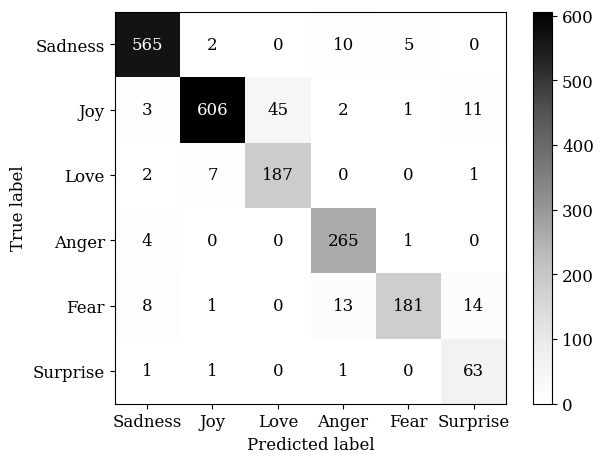

In [ ]:
# More fitting font etc.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 12
})

ConfusionMatrixDisplay(confusion_matrix(task_definitions[0]["dataset"]["test"].with_format("numpy")["labels"],  np.argmax(test_set_predictions, axis=1)), display_labels=dict([(value.capitalize(), key) for key, value in task_definitions[0]["labels"].items()])).plot(cmap="Greys")

plt.tight_layout()

plt.savefig("confusion_matrix.pdf")
plt.show()

In [ ]:
# Visualization of the embeddings produced by the baseline model
mean_last_hidden_states = np.empty(shape=(0,768))
labels_numpy = task_definitions[0]["dataset"]["test"].with_format("numpy")["labels"][:1000]

# Limit the samples to half the size to keep the plot more readable
for batch in range(int(len(task_definitions[0]["dataset"]["test"]) / 2 / 100)):
  range_start = batch * 100
  range_end = batch * 100 + 100

  with torch.no_grad():
    batch_last_hidden_states = model(**task_definitions[0]["dataset"]["test"][range_start:range_end], return_dict=True, output_hidden_states=True)["last_hidden_state"]

    input_mask_expanded = task_definitions[0]["dataset"]["test"][range_start:range_end]["attention_mask"].unsqueeze(-1).expand(batch_last_hidden_states.size()).float()
    mean_embeddings = torch.sum(batch_last_hidden_states * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

    mean_last_hidden_states = np.concatenate((mean_last_hidden_states, mean_embeddings.detach().cpu().numpy()), axis=0)

print(mean_last_hidden_states.shape)

(1000, 768)


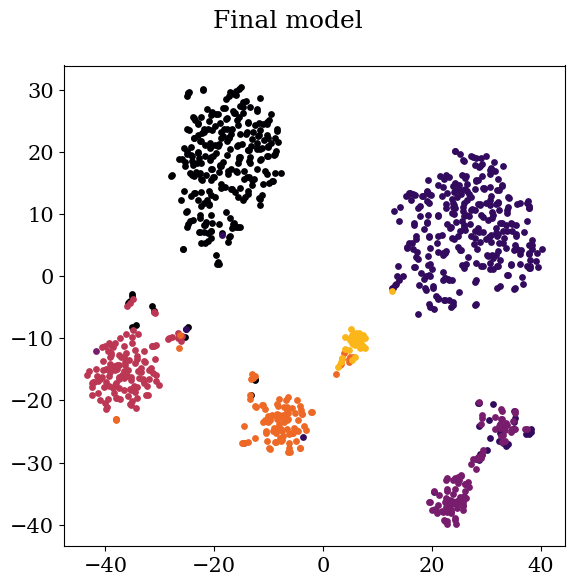

In [ ]:
pca = PCA(n_components=50)

pca_mean_embeddings_pca = pca.fit_transform(mean_last_hidden_states)

t_sne = TSNE(n_components=2)

pca_mean_embeddings_t_sne = t_sne.fit_transform(pca_mean_embeddings_pca)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot()

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 15
})

markers = ["o", "s", "*", "v", "D", "p"]
colors = plt.get_cmap("inferno")(np.linspace(0, 1, 7)[:6])

fig.suptitle("Final model")

for label_index, color, marker in zip(range(len(task_definitions[0]["labels"].keys())), colors, markers):
  sample_indexes = [i for i, x in enumerate(labels_numpy) if x == label_index]

  label = task_definitions[0]["labels"][label_index].capitalize()

  ax.scatter(pca_mean_embeddings_t_sne[sample_indexes, 0], pca_mean_embeddings_t_sne[sample_indexes, 1], s=15, color=color, label=label)

plt.tight_layout()

plt.savefig("inter_dataset_approach_final_model_embeddings.pdf")

plt.show()

In [ ]:
# Same larger unseen dataset evaluation as with the baseline model
unseen_test_set_macro_f1 = []

for unseen_test_set_index in range(int(50000 / 2000)):
  subset_range = range(2000 * unseen_test_set_index, 2000 * (unseen_test_set_index + 1))
  subset = emotion_dataset_unseen.select(subset_range)

  predictions = trainer.predict(subset)[0]
  labels = subset.with_format("numpy")["labels"]

  unseen_test_set_macro_f1.append(f1_score(labels, np.argmax(predictions, axis=-1), average="macro"))

print(f"Mean macro F1: {sum(unseen_test_set_macro_f1) / len(unseen_test_set_macro_f1)}")
print(f"All macro F1 values: {unseen_test_set_macro_f1}")

Mean macro F1: 0.9026215512204981
All macro F1 values: [0.9129726910087833, 0.8976850294510704, 0.9093382296761843, 0.9028624036378866, 0.9007624819625852, 0.8905577430320374, 0.9041284839938962, 0.8977797357808249, 0.9019412467585487, 0.8963528470965407, 0.913877671606896, 0.9053900676591861, 0.9174140108571436, 0.8861467546755769, 0.9020269667868276, 0.9008271039416073, 0.8891228155176935, 0.9028165811978428, 0.9112653560657747, 0.8968095627987824, 0.9035794486873369, 0.9104753986210907, 0.8973333215043101, 0.8998261771493316, 0.914246651044698]


In [23]:
# Calculate metrics also for weighted F1 and accuracy
unseen_test_metrics = {
    "weighted_f1": [],
    "accuracy": [],
}

for unseen_test_set_index in range(int(50000 / 2000)):
  subset_range = range(2000 * unseen_test_set_index, 2000 * (unseen_test_set_index + 1))
  subset = emotion_dataset_unseen.select(subset_range)

  predictions = trainer.predict(subset)[0]
  labels = subset.with_format("numpy")["labels"]

  unseen_test_metrics["weighted_f1"].append(f1_score(labels, np.argmax(predictions, axis=-1), average="weighted"))
  unseen_test_metrics["accuracy"].append(accuracy_score(labels, np.argmax(predictions, axis=-1)))

for metric_name, values in unseen_test_metrics.items():
  print(f"Mean {metric_name}: {sum(values) / len(values)}")
  print(f"All {metric_name} values: {values}")

Mean weighted_f1: 0.9301791415397119
All weighted_f1 values: [0.9237702087260098, 0.925615637983434, 0.9356276305807328, 0.9369855432079055, 0.9304449794641401, 0.9341162194060733, 0.9318022771328186, 0.9322775890161757, 0.9309091266021459, 0.9321905233055227, 0.937403465688477, 0.9254145611772303, 0.9341811255508801, 0.9228877447440437, 0.9317939761808438, 0.9244300981861445, 0.9317167859971793, 0.9132780069821159, 0.9329584865870324, 0.934446829647754, 0.9272962519014272, 0.9329545913660083, 0.9261307411129418, 0.9238019687501324, 0.9420441691956298]
Mean accuracy: 0.92938
All accuracy values: [0.9235, 0.925, 0.935, 0.936, 0.9295, 0.933, 0.931, 0.9315, 0.9295, 0.931, 0.9365, 0.925, 0.934, 0.922, 0.9315, 0.924, 0.9305, 0.9125, 0.932, 0.9335, 0.9265, 0.932, 0.9255, 0.9225, 0.9415]


# Statistical significance testing

Lastly the statistical significance testing is performed comparing the macro F1 scores of the baseline model and final model in this approach. The difference in the mean macro F1 scores is calculated in addition to checking if the score distribution differ from the normal distribution. The statistical significance testing is done here using the paired T-test and the Wilcoxon signed rank test, but the paired T-test was selected in the thesis.

In [24]:
# Macro F1 metrics of unsees test datasets, where at each index has is for a separate test dataset
baseline_macro_f1_metrics = [0.8901908303448115, 0.9041255305644397, 0.8866659303156545, 0.8778461789610499, 0.8933114767686964, 0.8982536372619032, 0.892897178680477, 0.8861323901906841, 0.8848415003046971, 0.8849754355763326, 0.8977356824717343, 0.8965353745999652, 0.8864821461587155, 0.8999334219737181, 0.8954630344894844, 0.8803189409669264, 0.8993583034733043, 0.8773820402197702, 0.8882329482776107, 0.8921379097826687, 0.8884501040884812, 0.8945247647779869, 0.8880074725875035, 0.8866071433242072, 0.8964122481880815]
final_macro_f1_metrics = [0.9129726910087833, 0.8976850294510704, 0.9093382296761843, 0.9028624036378866, 0.9007624819625852, 0.8905577430320374, 0.9041284839938962, 0.8977797357808249, 0.9019412467585487, 0.8963528470965407, 0.913877671606896, 0.9053900676591861, 0.9174140108571436, 0.8861467546755769, 0.9020269667868276, 0.9008271039416073, 0.8891228155176935, 0.9028165811978428, 0.9112653560657747, 0.8968095627987824, 0.9035794486873369, 0.9104753986210907, 0.8973333215043101, 0.8998261771493316, 0.914246651044698]

print(f"Difference in mean macro F1: {(sum(final_macro_f1_metrics) / len(final_macro_f1_metrics)) - (sum(baseline_macro_f1_metrics) / len(baseline_macro_f1_metrics))}", end="\n\n")

print(f"Normal distribution baseline: {normaltest(baseline_macro_f1_metrics).pvalue}")
print(f"Normal distribution final: {normaltest(final_macro_f1_metrics).pvalue}", end="\n\n")

print(f"wilcoxon: {wilcoxon(final_macro_f1_metrics, baseline_macro_f1_metrics, alternative="greater")}")
print(f"paired t-test: {ttest_rel(final_macro_f1_metrics, baseline_macro_f1_metrics, alternative="greater")}")

Difference in mean macro F1: 0.011948686246541995

Normal distribution baseline: 0.8213025865548989
Normal distribution final: 0.9662021005693047

wilcoxon: WilcoxonResult(statistic=np.float64(297.0), pvalue=np.float64(4.4018030166625977e-05))
paired t-test: TtestResult(statistic=np.float64(5.137107157272577), pvalue=np.float64(1.4690098255594875e-05), df=np.int64(24))
